# Projet MLOPS : Prévision de défauts

Le projet ci-suivant, réalisé dans le cadre d'un exercice académique du module MLOPS, de construire un modèle prédictif qui estime la probabilité de défaut pour chaque client en fonction de ses caractéristiques. 

# 1. Prétraitement de la donnée

In [25]:
# Chargement des bibliothèques nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

In [5]:
# Chargement du dataset
df = pd.read_csv('data/Loan_Data.csv')

# Affichage des premières lignes du dataset
df.head()

,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
0,8153374,0,5221.545193,3915.471226,78039.38546,5,605,0
1,7442532,5,1958.928726,8228.752520,26648.43525,2,572,1
2,2256073,0,3363.009259,2027.830850,65866.71246,4,602,0
3,4885975,0,4766.648001,2501.730397,74356.88347,5,612,0
4,4700614,1,1345.827718,1768.826187,23448.32631,6,631,0


In [6]:
# Type de données, valeurs manquantes et statistiques descriptives
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               10000 non-null  int64  
 1   credit_lines_outstanding  10000 non-null  int64  
 2   loan_amt_outstanding      10000 non-null  float64
 3   total_debt_outstanding    10000 non-null  float64
 4   income                    10000 non-null  float64
 5   years_employed            10000 non-null  int64  
 6   fico_score                10000 non-null  int64  
 7   default                   10000 non-null  int64  
dtypes: float64(3), int64(5)
memory usage: 625.1 KB


customer_id                 0
credit_lines_outstanding    0
loan_amt_outstanding        0
total_debt_outstanding      0
income                      0
years_employed              0
fico_score                  0
default                     0
dtype: int64

Nous partons d'une bonne base. Toutes les données sont numériques. Notre cible défaut est *default*

Nous réaliserons maintenant une analyse exploratoire pour étudier les corrélations entre la variable cible et d'autres facteurs

<Axes: title={'center': 'Répartition des cas de défaut'}>

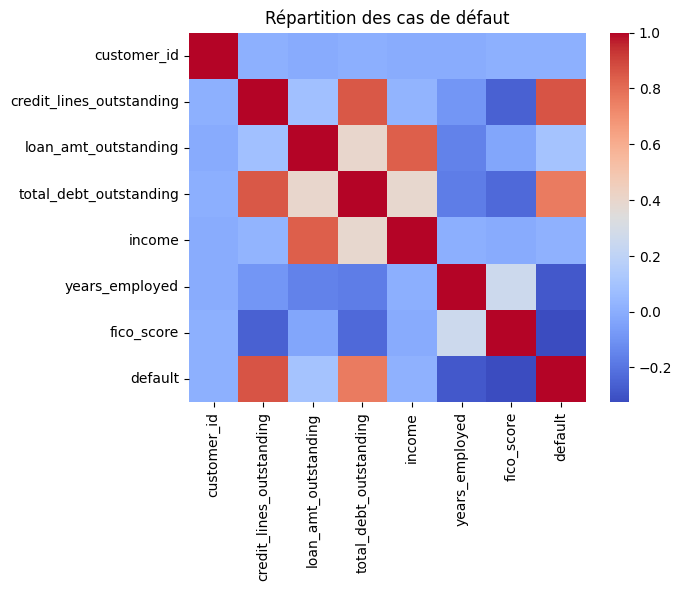

In [7]:
sns.countplot(x="default", data=df)
plt.title("Répartition des cas de défaut")

# Corrélation des variables financières
sns.heatmap(df.corr(), cmap="coolwarm", annot=False)

•	Les variables  *total_debt_outstanding*  et  *credit_lines_outstanding*  ont une forte corrélation positive avec la variable cible  default . Cela signifie que plus la dette totale ou les lignes de crédit en cours sont élevées, plus le risque de défaut augmente.

•	Le revenu (income) semble moins corrélé à la variable défaut, indiquant que ce facteur pourrait être moins discriminant dans ce dataset.

•	Le score de crédit (fico_score) a une corrélation négative modérée avec la variable défaut, ce qui correspond à l’intuition : un score de crédit plus élevé diminue le risque de défaut.

•	D’autres relations comme entre  *loan_amt_outstanding*  et  *total_debt_outstanding*  sont également fortes, ce qui peut influencer la multicolinéarité dans certains modèles.

In [8]:
# Prétraitement des données et séparation du jeu de données

# Suppression de l'identifiant
X = df.drop(columns=['customer_id', 'default'])
y = df['default']

# Séparation
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Normalisation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1630
           1       1.00      0.99      1.00       370

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



<Axes: >

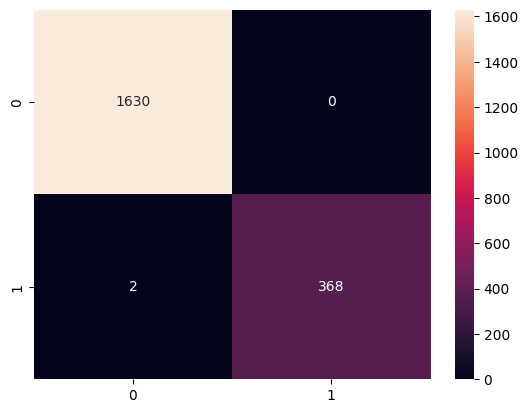

In [11]:
# Premier test 

model = LogisticRegression()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

print(classification_report(y_test, y_pred))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')

In [40]:
# Entrainement sur plusieurs modèles

# Définition des modèles

models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

best_f1 = 0
best_model = None
best_name = ""

# Entraînement et prédiction
results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    results[name] = preds

In [17]:
# Tests sur plusieurs modèles

for name, preds in results.items():
    print(f"\n{name} :\n")
    print(classification_report(y_test, preds))
    cm = confusion_matrix(y_test, preds)
    print("Matrice de confusion :\n", cm)



Logistic Regression :

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1630
           1       1.00      0.99      1.00       370

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000

Matrice de confusion :
 [[1630    0]
 [   2  368]]

Decision Tree :

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1630
           1       0.98      0.99      0.99       370

    accuracy                           0.99      2000
   macro avg       0.99      0.99      0.99      2000
weighted avg       1.00      0.99      1.00      2000

Matrice de confusion :
 [[1624    6]
 [   4  366]]

Random Forest :

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1630
           1       0.99      0.99      0.99       370

    accuracy        

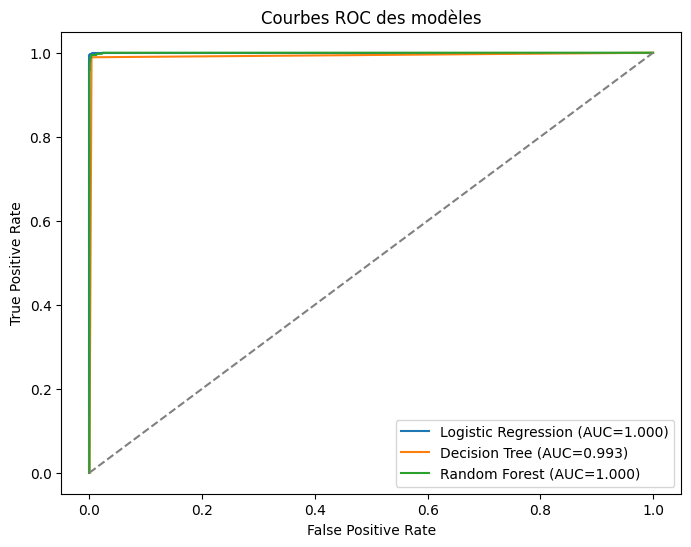

In [20]:
# visualisation des matrices de confusion
plt.figure(figsize=(8, 6))
for name, model in models.items():
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Courbes ROC des modèles")
plt.legend()
plt.show()

•	Logistic Regression : quasi-parfait, deux défauts non détectés (2 FN) et aucun faux positif ; résultats étonnants, probablement dûs à une forte séparation des données ou un risque minime de sur-apprentissage sur ce jeu de données.

•	Decision Tree : très solide, mais légèrement moins précis pour la classe défaut : 4 FN, 6 FP ; peut être plus sensible au sur-apprentissage si le dataset est bruité.

•	Random Forest : intermédiaire, très proche de la régression logistique, avec 5 FN et 3 FP ; meilleure robustesse et souvent plus stable lors de la généralisation.

Concernant le choix du modèle, nous éliminerons le *Decision Tree*. Nous partirons sur la *Random Forest* pour le déploiement et conserver la *Logistric Regression* pour l'explicabilité en backup.

# 2. Intégration de MLFlow : tracking des runs

In [22]:
import mlflow
import mlflow.sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

experiment_name = "default-risk-prediction"
mlflow.set_experiment(experiment_name)

with mlflow.start_run(run_name="RandomForest_baseline"):
    rf = RandomForestClassifier(random_state=42)
    rf.fit(X_train_scaled, y_train)
    preds = rf.predict(X_test_scaled)
    f1 = f1_score(y_test, preds)
    mlflow.log_param("n_estimators", rf.n_estimators)
    mlflow.log_param("random_state", rf.random_state)
    mlflow.log_metric("f1_score", f1)
    mlflow.sklearn.log_model(rf, "model")
    print("Run logged with F1-score:", f1)

2025/10/17 22:45:01 INFO mlflow.tracking.fluent: Experiment with name 'default-risk-prediction' does not exist. Creating a new experiment.
2025/10/17 22:45:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/10/17 22:45:12 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Run logged with F1-score: 0.989159891598916


In [39]:
from mlflow.models.signature import infer_signature
import numpy as np

# Préparer un input_example (exemple d'entrée en DataFrame ou numpy array)
input_example = X_train_scaled[:1]  # ou pd.DataFrame([...])

# Inférer la signature des entrées/sorties
signature = infer_signature(input_example, model.predict(input_example))

# Log du modèle avec paramètres recommandés
mlflow.sklearn.log_model(
    sk_model=model,
    name="model",
    input_example=input_example,
    signature=signature
)


In [34]:
# Sauvegarde du modèle et du scaler
joblib.dump(rf, "models/rf_model.pkl")
joblib.dump(scaler, "models/scaler.pkl")
print("Modèle et scaler sauvegardés avec succès.")

Modèle et scaler sauvegardés avec succès.


In [35]:
# Pipeline d'inférence

# Chargement des objets
rf = joblib.load("models/rf_model.pkl")
scaler = joblib.load("models/scaler.pkl")

# Exemples de prédiction
def predict_default(example_dict):
    # example_dict: dictionnaire ou DataFrame une ligne
    # Ex: {"credit_lines_outstanding":2, ...}
    df = pd.DataFrame([example_dict])
    X_scaled = scaler.transform(df)
    proba = rf.predict_proba(X_scaled)[0, 1]
    label = rf.predict(X_scaled)[0]
    return {"proba_defaut": float(proba), "defaut": int(label)}

# Exemple d'appel :
example = {
    "credit_lines_outstanding": 2,
    "loan_amt_outstanding": 4000,
    "total_debt_outstanding": 7000,
    "income": 55000,
    "years_employed": 3,
    "fico_score": 650
}
result = predict_default(example)
print(result)


{'proba_defaut': 0.0, 'defaut': 0}


In [36]:
# tests

# Profil test - différents exemples représentatifs
test_examples = [
    {
        "credit_lines_outstanding": 0,
        "loan_amt_outstanding": 2000,
        "total_debt_outstanding": 1500,
        "income": 70000,
        "years_employed": 5,
        "fico_score": 750
    },
    {
        "credit_lines_outstanding": 5,
        "loan_amt_outstanding": 10000,
        "total_debt_outstanding": 8000,
        "income": 35000,
        "years_employed": 1,
        "fico_score": 550
    },
    {
        "credit_lines_outstanding": 3,
        "loan_amt_outstanding": 15000,
        "total_debt_outstanding": 11000,
        "income": 45000,
        "years_employed": 2,
        "fico_score": 630
    }
]

# Fonction prédictive définie précédemment
def predict_default(example_dict):
    df = pd.DataFrame([example_dict])
    X_scaled = scaler.transform(df)
    proba = rf.predict_proba(X_scaled)[0, 1]
    label = rf.predict(X_scaled)[0]
    return {"proba_defaut": float(proba), "defaut": int(label)}

# Tests automatiques sur chaque profil
results = []
for i, example in enumerate(test_examples):
    pred = predict_default(example)
    example_result = example.copy()
    example_result.update(pred)
    results.append(example_result)

# Convertir en DataFrame pour affichage
results_df = pd.DataFrame(results)
print(results_df)


   credit_lines_outstanding  loan_amt_outstanding  total_debt_outstanding  \
0                         0                  2000                    1500   
1                         5                 10000                    8000   
2                         3                 15000                   11000   

   income  years_employed  fico_score  proba_defaut  defaut  
0   70000               5         750          0.00       0  
1   35000               1         550          0.91       1  
2   45000               2         630          0.90       1  


In [47]:
import os
from imblearn.pipeline import Pipeline as ImbPipeline
import pickle
from imblearn.over_sampling import RandomOverSampler
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, roc_auc_score


# Définition des chemins des dossiers
MLARTIFACTS_DIR = "./mlruns_artifacts"
MODELS_DIR = "./saved_models"
os.makedirs(MLARTIFACTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

# Chargement des données
df = pd.read_csv("data/Loan_Data.csv")
X = df.drop(columns=['customer_id', 'default'])
y = df['default']

# Split train/test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# Initialisation variables
best_f1 = 0
best_model = None
best_name = None

# Models à tester
models = {
    "Logistic Regression": LogisticRegression(max_iter=500, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

# Client MLflow
from mlflow.tracking import MlflowClient
client = MlflowClient()

for name, model in models.items():
    artifact_path = os.path.join(MLARTIFACTS_DIR, name)
    os.makedirs(artifact_path, exist_ok=True)

    try:
        experiment_id = client.create_experiment(name=name, artifact_location=artifact_path)
    except mlflow.exceptions.MlflowException:
        experiment = client.get_experiment_by_name(name)
        experiment_id = experiment.experiment_id

    mlflow.set_experiment(name)

    with mlflow.start_run(run_name=f"{name}_run"):

        pipeline = ImbPipeline([
            ('oversample', RandomOverSampler(random_state=42)),
            ('classifier', model)
        ])
        pipeline.fit(X_train, y_train)

        # Prédictions train et test
        y_train_pred = pipeline.predict(X_train)
        y_test_pred = pipeline.predict(X_test)

        # Métriques train (console)
        acc_train = accuracy_score(y_train, y_train_pred)
        f1_train = f1_score(y_train, y_train_pred)
        prec_train = precision_score(y_train, y_train_pred)
        recall_train = recall_score(y_train, y_train_pred)
        tn_train, fp_train, fn_train, tp_train = confusion_matrix(y_train, y_train_pred).ravel()
        print(f"\n {name} : Métriques train ")
        print(f"Accuracy: {acc_train:.3f}, F1: {f1_train:.3f}, Precision: {prec_train:.3f}, Recall: {recall_train:.3f}")
        print(f"Vrais positifs: {tp_train}, Vrais négatifs: {tn_train}, Faux positifs: {fp_train}, Faux négatifs: {fn_train}")
        if abs(f1_train - f1_score(y_test, y_test_pred)) > 0.05:
            print(" Signe possible d'overfitting")
        else:
            print(" Pas de signe d'overfitting évident")

        # Métriques test (logging MLflow)
        acc_test = accuracy_score(y_test, y_test_pred)
        f1_test = f1_score(y_test, y_test_pred)
        prec_test = precision_score(y_test, y_test_pred)
        recall_test = recall_score(y_test, y_test_pred)
        tn_test, fp_test, fn_test, tp_test = confusion_matrix(y_test, y_test_pred).ravel()
        fpr_test = fp_test / (fp_test + tn_test)
        fnr_test = fn_test / (fn_test + tp_test)
        roc_auc_test = roc_auc_score(y_test, pipeline.predict_proba(X_test)[:,1]) if hasattr(model, "predict_proba") else None

        mlflow.log_param("model_name", name)
        mlflow.log_metric("accuracy", acc_test)
        mlflow.log_metric("f1_score", f1_test)
        mlflow.log_metric("precision", prec_test)
        mlflow.log_metric("recall_test", recall_test)
        mlflow.log_metric("vrais_positifs", tp_test)
        mlflow.log_metric("vrais_negatifs", tn_test)
        mlflow.log_metric("faux_positifs", fp_test)
        mlflow.log_metric("faux_negatifs", fn_test)
        mlflow.log_metric("taux_faux_positifs", fpr_test)
        mlflow.log_metric("taux_faux_negatifs", fnr_test)
        if roc_auc_test is not None:
            mlflow.log_metric("roc_auc", roc_auc_test)

        # Matrice de confusion (graphique)
        cm = confusion_matrix(y_test, y_test_pred)
        fig, ax = plt.subplots(figsize=(6,5))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
        plt.xlabel("Prédit")
        plt.ylabel("Réel")
        plt.title(f"Matrice de confusion - {name}")
        plt.tight_layout()
        cm_file = os.path.join(artifact_path, f"confusion_matrix_{name}.png")
        plt.savefig(cm_file)
        plt.close()
        mlflow.log_artifact(cm_file)

        # Feature importance si disponible
        if hasattr(model, "feature_importances_"):
            importances = model.feature_importances_
            fig, ax = plt.subplots(figsize=(7,5))
            sns.barplot(x=X.columns, y=importances, ax=ax)
            plt.xticks(rotation=45)
            plt.title(f"Feature Importance - {name}")
            plt.tight_layout()
            feat_file = os.path.join(artifact_path, f"feature_importance_{name}.png")
            plt.savefig(feat_file)
            plt.close()
            mlflow.log_artifact(feat_file)

        # Sauvegarder meilleur modèle
        if f1_test > best_f1:
            best_f1 = f1_test
            best_model = pipeline
            best_name = name
            model_file = os.path.join(MODELS_DIR, f"BestModel_{name}_{best_f1:.4f}.pkl")
            with open(model_file, "wb") as f:
                pickle.dump(best_model, f)
            print(f"-> Nouveau meilleur modèle sauvegardé : {model_file}")

        # Logging complet du modèle MLflow avec signature
        input_example = X_test.iloc[:1]
        signature = infer_signature(X_test, pipeline.predict(X_test))
        mlflow.sklearn.log_model(
            sk_model=pipeline,
            name="model",
            signature=signature,
            input_example=input_example
        )

/Users/boss/Documents/learning/vs_code/ml_ops/mlops/lib/python3.9/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/boss/Documents/learning/vs_code/ml_ops/mlops/lib/python3.9/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(



 Logistic Regression : Métriques train 
Accuracy: 0.996, F1: 0.990, Precision: 0.981, Recall: 1.000
Vrais positifs: 1481, Vrais négatifs: 6490, Faux positifs: 29, Faux négatifs: 0
 Pas de signe d'overfitting évident
-> Nouveau meilleur modèle sauvegardé : ./saved_models/BestModel_Logistic Regression_0.9920.pkl


/Users/boss/Documents/learning/vs_code/ml_ops/mlops/lib/python3.9/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
/Users/boss/Documents/learning/vs_code/ml_ops/mlops/lib/python3.9/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `skle


 Decision Tree : Métriques train 
Accuracy: 1.000, F1: 1.000, Precision: 1.000, Recall: 1.000
Vrais positifs: 1481, Vrais négatifs: 6519, Faux positifs: 0, Faux négatifs: 0
 Pas de signe d'overfitting évident


/Users/boss/Documents/learning/vs_code/ml_ops/mlops/lib/python3.9/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
/Users/boss/Documents/learning/vs_code/ml_ops/mlops/lib/python3.9/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `skle


 Random Forest : Métriques train 
Accuracy: 1.000, F1: 1.000, Precision: 1.000, Recall: 1.000
Vrais positifs: 1481, Vrais négatifs: 6519, Faux positifs: 0, Faux négatifs: 0
 Pas de signe d'overfitting évident


/Users/boss/Documents/learning/vs_code/ml_ops/mlops/lib/python3.9/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


In [48]:
print(f"Meilleur modèle : {best_name} avec F1-score = {best_f1:.4f}")

Meilleur modèle : Logistic Regression avec F1-score = 0.9920
